# 04 — Évaluation

**Début** : charge `03_train_model`. **Fin** : métriques + images + state.

[03_train_model] État chargé ← /home/light/Documents/DO5/MLOps/mlops-pokegen/artifacts/pipeline/steps/03_train_model/state.json


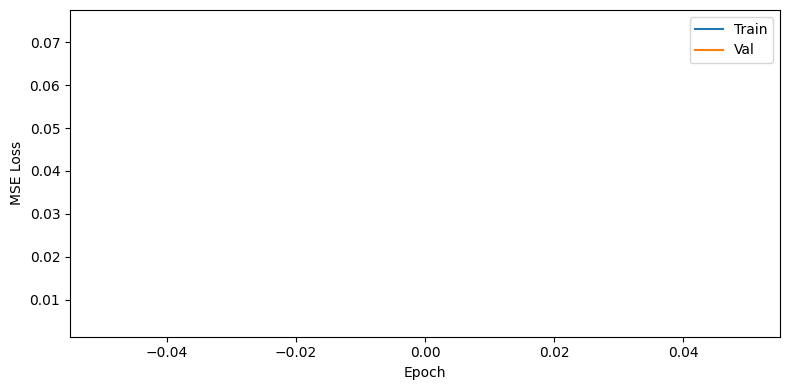

Métriques: /home/light/Documents/DO5/MLOps/mlops-pokegen/artifacts/pipeline/steps/04_evaluation/metrics.json


In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "shared").exists():
    REPO_ROOT = REPO_ROOT.parent

sys.path.insert(0, str(REPO_ROOT))

import json
import copy
import random

import matplotlib.pyplot as plt
import torch
from PIL import Image
from diffusers import StableDiffusionPipeline

from shared.paths import STEP_04_LOSS_PNG, STEP_04_METRICS, STEP_04_SAMPLES_PNG, STEP_03_CHECKPOINT
from shared.pokemon_dataset import (
    build_loaders_from_manifest,
    get_metadata_from_png,
    metadata_to_conditioning,
    pick_device,
)
from shared.sd_lora_models import DEFAULT_MODEL_ID, build_sd_lora_stack
from shared.step_artifacts import load_previous_step_output, rel_path, resolve_path, save_step_output

prev = load_previous_step_output("04_evaluation")
manifest_path = resolve_path(prev["manifest_path"])

checkpoint_path = resolve_path(prev["checkpoint_path"])

model_id = prev.get("model_id", DEFAULT_MODEL_ID)

ckpt = torch.load(checkpoint_path, map_location="cpu", weights_only=False)
train_losses = ckpt["train_losses"]
val_losses = ckpt["val_losses"]

plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train")
plt.plot(val_losses, label="Val")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.tight_layout()
STEP_04_LOSS_PNG.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(STEP_04_LOSS_PNG, dpi=120)
plt.show()

metrics = {"train_losses": train_losses, "val_losses": val_losses, "epochs": len(train_losses)}
STEP_04_METRICS.write_text(json.dumps(metrics, indent=2), encoding="utf-8")
print(f"Métriques: {STEP_04_METRICS}")


In [ ]:
device = pick_device()
train_dataset, val_dataset, _, _, tokenizer = build_loaders_from_manifest(manifest_path)
vae, unet, text_encoder, noise_scheduler = build_sd_lora_stack(device, model_id=model_id)
ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
unet.load_state_dict(ckpt["unet_state_dict"])
unet.eval()

unet_copy = copy.deepcopy(unet)
pipe = StableDiffusionPipeline.from_pretrained(
    model_id,
    vae=vae,
    unet=unet_copy.merge_and_unload(),
    text_encoder=text_encoder,
    tokenizer=tokenizer,
    safety_checker=None,
).to(device)
del unet_copy

def get_val_path(i):
    return val_dataset.dataset.image_paths[int(val_dataset.indices[i])]

n = min(1, len(val_dataset))
indices = random.sample(range(len(val_dataset)), n)
fig, axes = plt.subplots(2, n, figsize=(4 * n, 8))
if n == 1:
    axes = axes.reshape(2, 1)
for col, i in enumerate(indices):
    path = get_val_path(i)
    cond = metadata_to_conditioning(get_metadata_from_png(path))
    axes[0, col].imshow(pipe(cond, num_inference_steps=20, guidance_scale=7.5).images[0])
    axes[0, col].axis("off")
    axes[1, col].imshow(Image.open(path).convert("RGB").resize((512, 512)))
    axes[1, col].axis("off")
plt.tight_layout()
plt.savefig(STEP_04_SAMPLES_PNG, dpi=120)
plt.show()

save_step_output("04_evaluation", {
    "checkpoint_path": prev["checkpoint_path"],
    "manifest_path": prev["manifest_path"],
    "model_id": model_id,
    "metrics_path": rel_path(STEP_04_METRICS),
    "loss_curves_path": rel_path(STEP_04_LOSS_PNG),
    "eval_samples_path": rel_path(STEP_04_SAMPLES_PNG),
    "final_val_loss": val_losses[-1] if val_losses else None,
})


Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

You have disabled the safety checker for <class 'diffusers.pipelines.stable_diffusion.pipeline_stable_diffusion.StableDiffusionPipeline'> by passing `safety_checker=None`. Ensure that you abide to the conditions of the Stable Diffusion license and do not expose unfiltered results in services or applications open to the public. Both the diffusers team and Hugging Face strongly recommend to keep the safety filter enabled in all public facing circumstances, disabling it only for use-cases that involve analyzing network behavior or auditing its results. For more information, please have a look at https://github.com/huggingface/diffusers/pull/254 .
Token indices sequence length is longer than the specified maximum sequence length for this model (360 > 77). Running this sequence through the model will result in indexing errors
The following part of your input was truncated because CLIP can only handle sequences up to 77 tokens: ['" evolvefrom ": null , " hp ": 5 0 , " id ": " sv 0 9 - 0 7 4 

  0%|          | 0/20 [00:00<?, ?it/s]